In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from src.kinetics_model import solve_kinetics, calculate_conversion
from src.hvo_model import solve_hvo_kinetics, calculate_hvo_conversion

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

print("✅ Librerie importate")

✅ Librerie importate


In [2]:
# Parametri FAME (calibrati)
k_fame = [0.0666, 1.0, 1.0]
TG0 = 1.0
initial_C_fame = [TG0, 0, 0, 0, 0]
t = np.linspace(0, 60, 100)

# Simula FAME
solution_fame = solve_kinetics(initial_C_fame, t, k_fame)
conversion_fame = calculate_conversion(solution_fame)

print(f"FAME - Conversione a 60 min: {conversion_fame[-1]:.1f}%")

FAME - Conversione a 60 min: 98.2%


In [3]:
# Parametri HVO (da letteratura)
k_hvo = [0.05]  # L/(mol·min)
H2_initial = 3.0
initial_C_hvo = [TG0, H2_initial, 0, 0]

# Simula HVO
solution_hvo = solve_hvo_kinetics(initial_C_hvo, t, k_hvo)
conversion_hvo = calculate_hvo_conversion(solution_hvo)

print(f"HVO - Conversione a 60 min: {conversion_hvo[-1]:.1f}%")

HVO - Conversione a 60 min: 90.0%


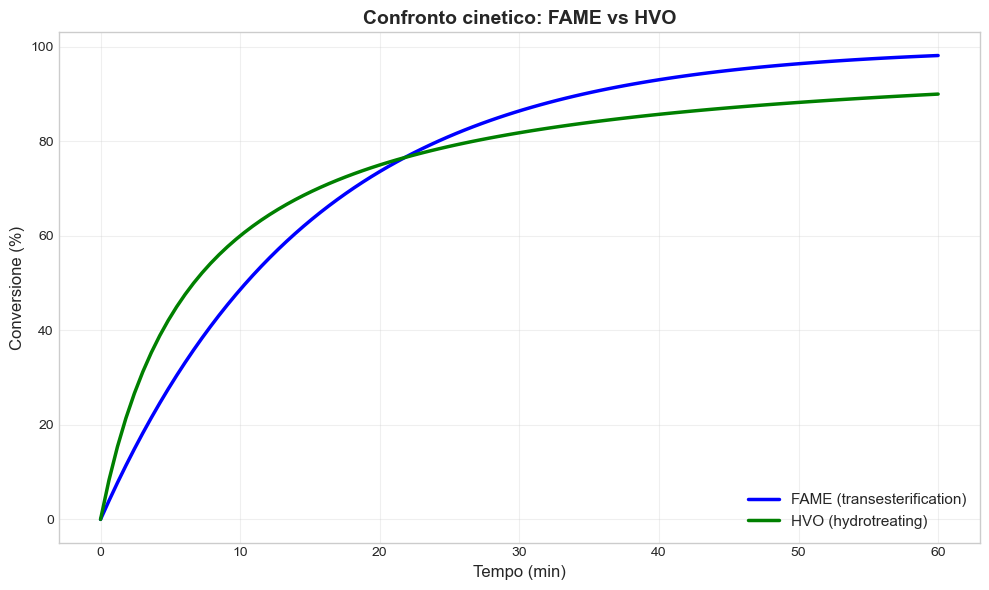

✅ Grafico salvato in output/hvo_kinetics_comparison.png


In [4]:
# Grafico comparativo cinetico
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(t, conversion_fame, 'b-', linewidth=2.5, label='FAME (transesterification)')
ax.plot(t, conversion_hvo, 'g-', linewidth=2.5, label='HVO (hydrotreating)')

ax.set_xlabel('Tempo (min)', fontsize=12)
ax.set_ylabel('Conversione (%)', fontsize=12)
ax.set_title('Confronto cinetico: FAME vs HVO', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../output/hvo_kinetics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Grafico salvato in output/hvo_kinetics_comparison.png")


📊 Tabella comparativa FAME vs HVO:

           Proprietà                 FAME                             HVO
            Processo Transesterificazione                 Idrotrattamento
       Materie prime Oli vegetali, grassi Oli vegetali, grassi, oli usati
Compatibilità motori   Richiede modifiche      100% compatibile (drop-in)
    Numero di cetano                50-60                           70-90
Stabilità ossidativa                Bassa                            Alta
             Drop-in                   No                              Sì
 Tendenza mercato EU              Declino                 Crescita rapida


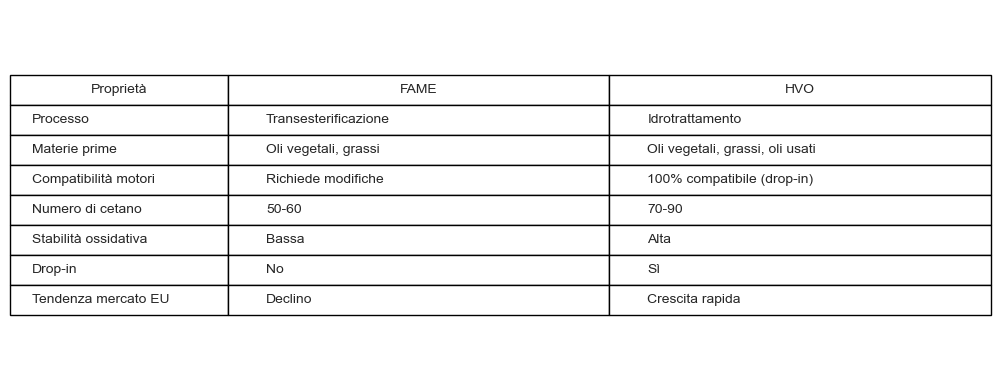


✅ Tabella salvata in output/hvo_technical_comparison.png


In [5]:
# Tabella comparativa tecnica
data = {
    'Proprietà': [
        'Processo', 
        'Materie prime', 
        'Compatibilità motori',
        'Numero di cetano',
        'Stabilità ossidativa',
        'Drop-in',
        'Tendenza mercato EU'
    ],
    'FAME': [
        'Transesterificazione',
        'Oli vegetali, grassi',
        'Richiede modifiche',
        '50-60',
        'Bassa',
        'No',
        'Declino'
    ],
    'HVO': [
        'Idrotrattamento',
        'Oli vegetali, grassi, oli usati',
        '100% compatibile (drop-in)',
        '70-90',
        'Alta',
        'Sì',
        'Crescita rapida'
    ]
}

df_comparison = pd.DataFrame(data)
print("\n📊 Tabella comparativa FAME vs HVO:\n")
print(df_comparison.to_string(index=False))

# Salva tabella come immagine per il report
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=df_comparison.values, colLabels=df_comparison.columns,
                 cellLoc='left', loc='center', colWidths=[0.2, 0.35, 0.35])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)
plt.tight_layout()
plt.savefig('../output/hvo_technical_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Tabella salvata in output/hvo_technical_comparison.png")